In [218]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import pandas as pd
%config InlineBackend.figure_formats = ['svg']

In [249]:
def parse_criterion_mean_changes(file_name: str) -> [float]:
    result = []
    digit_pattern = r'[-+](?:[0-9]+.[0-9]+)'
    with open(file_name) as f:
        for line in f:
            line = line.replace("−", "-") # replacing strange Criterion minus sign, which is not actually minus
            matches = re.findall(f'change: \\[{digit_pattern}% ({digit_pattern})% {digit_pattern}%\\]', line)
            if matches:
                result.append(float(matches[0]))
    return result

def parse_tango_changes(file_name: str) -> [float]:
    result = []
    with open(file_name) as f:
        for line in f:
            matches = re.findall(r"([-+][0-9]+.[0-9]+)%\*?$", line)
            result.append(float(matches[0]))
    return result

In [271]:
experiment_path = "exp2"
data = pd.DataFrame({
    'tango': parse_tango_changes(f"{experiment_path}/tango.txt"),
    'criterion': parse_criterion_mean_changes(f"{experiment_path}/criterion.txt"),
    'criterion-in-place': parse_criterion_mean_changes(f"{experiment_path}/criterion-in-place.txt"),
})

data.describe()

,tango,criterion,criterion-in-place
count,493.000000,493.000000,493.000000
mean,0.131785,0.807869,0.592556
std,1.816033,4.334569,11.021201
min,-16.790000,-0.104400,-45.617000
25%,-0.070000,0.167900,-0.118100
50%,0.030000,0.266300,0.006000
75%,0.120000,0.389200,0.134100
max,19.030000,75.180000,145.510000


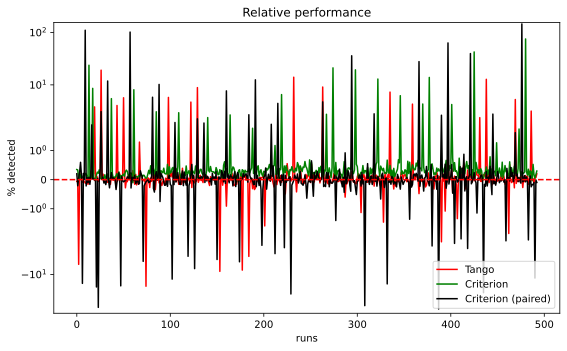

In [291]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(data.index, data['tango'], color='red', label="Tango")
ax.plot(data.index, data['criterion'], color='green', label="Criterion")
ax.plot(data.index, data['criterion-in-place'], color='black', label="Criterion (paired)")

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

ax.set_yscale('symlog')

ax.set_title('Relative performance')
ax.set_xlabel('runs')
ax.set_ylabel('% detected')

ax.legend()

plt.tight_layout()
plt.show()

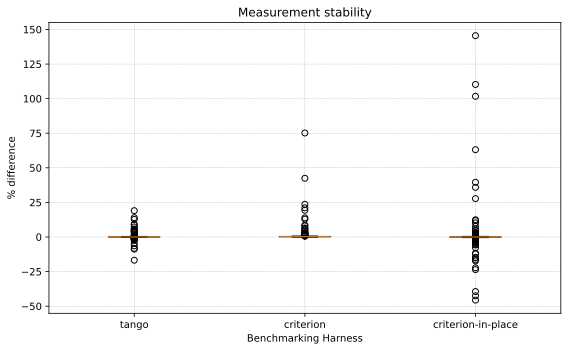

In [295]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([data[col] for col in data.columns], tick_labels=data.columns, showfliers=True, whis=1.5)
#ax.set_yscale('symlog')

ax.set_title('Measurement stability')
ax.set_xlabel('Benchmarking Harness')
ax.set_ylabel('% difference')
ax.grid(linestyle='--', linewidth=0.4)

plt.tight_layout()
plt.show()